# 11. Revision - Figure 4 (SHAP) regenerated for the finalized Table S2 model

**Why.** The Figure 4 SHAP summary plot in the original submission was produced from a *pre-harmonization* XGBoost configuration (learning_rate=0.01, gamma=0, min_child_weight=2, colsample_bytree=0.5, reg_alpha=0, reg_lambda=1.5) and was not regenerated during harmonization. This notebook redraws Figure 4 from the **finalized fixed hyperparameters (Table S2)**.

**Estimator used for SHAP.** SHAP values are computed with `shap.TreeExplainer` on the **uncalibrated base `XGBClassifier`** (the tree ensemble), *not* on the isotonic `CalibratedClassifierCV` that is deployed for probability output. TreeExplainer requires the raw tree structure; the isotonic wrapper is a monotone post-hoc transform of the score and has no tree structure to attribute. The base estimator here uses the identical hyperparameters, `scale_pos_weight`, seed, and KNN-imputed feature matrix as the deployed model's inner XGBoost, so the attributions describe the same decision function.

**No artifacts overwritten.** This notebook fits a fresh in-memory estimator for explanation only; it does **not** re-save `model/final_model_calibrated.pkl` or any other `.pkl`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
import shap
SEED = 8251
def find_data_dir():
    cands = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        cands += [base/'local_data', base/'stage_III_colon_edr'/'local_data']
    for c in cands:
        if c.exists(): return c
    raise FileNotFoundError('Place a local_data/ folder (with all_cases_prepared_for_ML.parquet) in the repo root; see README.')
DATA = find_data_dir(); FIGDIR = DATA.parent
deriv = pd.read_parquet(DATA/'all_cases_prepared_for_ML.parquet')
print('Data dir :', DATA)
print('Fig dir  :', FIGDIR)
print('Derivation n =', len(deriv), '| EDR-18m events =', int(deriv['edr_18m'].sum()))

Data dir : A:\DCR_Revision\_repo_work\local_data
Fig dir  : A:\DCR_Revision\_repo_work
Derivation n = 331 | EDR-18m events = 62


In [2]:
# --- Feature construction: identical to the deployed model (matches final_feature_columns.pkl and the old Fig 4) ---
features = ['AJCC_Substage', 'PNI', 'LNR', 'Differentiation']
def base_X(df):
    X = df[features].copy()
    X['PNI'] = pd.to_numeric(X['PNI'], errors='coerce')
    X['Differentiation'] = pd.to_numeric(X['Differentiation'], errors='coerce')
    X = pd.get_dummies(X, columns=['AJCC_Substage'])
    return X.replace([np.inf, -np.inf], np.nan)
dfx = deriv.dropna(subset=['edr_18m']).copy()
X = base_X(dfx); y = dfx['edr_18m'].astype(int)
print('Feature matrix:', X.shape)
print('Columns (plot order source):', list(X.columns))
# --- Finalized fixed hyperparameters (Table S2) ---
ratio = float((y == 0).sum() / (y == 1).sum())
XGB = dict(n_estimators=50, max_depth=2, learning_rate=0.05, gamma=1.0, min_child_weight=1,
           subsample=0.9, colsample_bytree=0.6, reg_alpha=0.5, reg_lambda=1.0,
           eval_metric='logloss', random_state=SEED, n_jobs=1)
print('scale_pos_weight (#neg/#pos) = %.4f' % ratio)

Feature matrix: (331, 6)
Columns (plot order source): ['PNI', 'LNR', 'Differentiation', 'AJCC_Substage_3A', 'AJCC_Substage_3B', 'AJCC_Substage_3C']
scale_pos_weight (#neg/#pos) = 4.3387


In [3]:
# --- Impute (KNN, k=5) then fit the UNCALIBRATED base XGBoost on the full derivation cohort ---
imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
xgb_base = XGBClassifier(scale_pos_weight=ratio, **XGB)
xgb_base.fit(X_imputed, y)
# --- SHAP on the base tree ensemble ---
explainer = shap.TreeExplainer(xgb_base)
shap_values = explainer.shap_values(X_imputed)
order = np.argsort(-np.abs(shap_values).mean(0))
print('Feature ranking by mean(|SHAP|):')
for r, i in enumerate(order, 1):
    print('  %d. %-22s mean|SHAP| = %.4f' % (r, X_imputed.columns[i], np.abs(shap_values[:, i]).mean()))

Feature ranking by mean(|SHAP|):
  1. AJCC_Substage_3C       mean|SHAP| = 0.3076
  2. LNR                    mean|SHAP| = 0.2331
  3. PNI                    mean|SHAP| = 0.0845
  4. AJCC_Substage_3A       mean|SHAP| = 0.0822
  5. Differentiation        mean|SHAP| = 0.0568
  6. AJCC_Substage_3B       mean|SHAP| = 0.0276


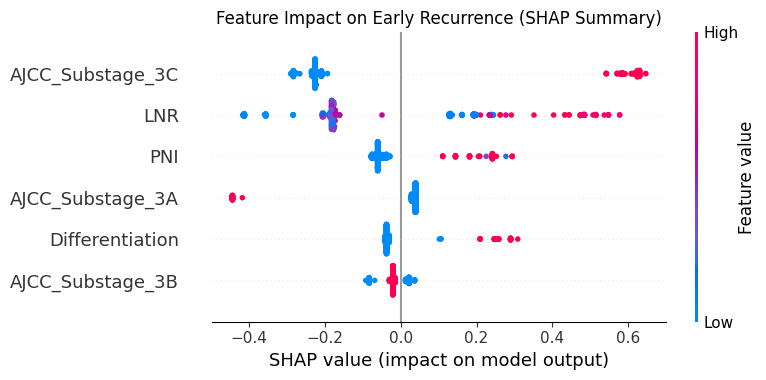

SAVED A:\DCR_Revision\_repo_work\Figure_4_SHAP_Plot_XGB.tiff (2847 KB)
SAVED A:\DCR_Revision\_repo_work\Figure_4_SHAP_Plot_XGB.pdf (39 KB)
SAVED A:\DCR_Revision\_repo_work\Figure_4_SHAP_Plot_XGB.png (142 KB)


In [4]:
# --- Figure 4: SHAP summary (beeswarm), same layout/labels as the original ---
plt.figure(figsize=(10, 8))
plt.title('Feature Impact on Early Recurrence (SHAP Summary)')
shap.summary_plot(shap_values, X_imputed, show=False)
plt.tight_layout()
tiff = FIGDIR/'Figure_4_SHAP_Plot_XGB.tiff'
pdf  = FIGDIR/'Figure_4_SHAP_Plot_XGB.pdf'
png  = FIGDIR/'Figure_4_SHAP_Plot_XGB.png'
plt.savefig(tiff, format='tiff', dpi=1200, bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})  # >= 1200 dpi, LZW (lossless)
plt.savefig(pdf,  format='pdf',  bbox_inches='tight')             # vector copy (DCR: vector OR >=1200 dpi)
plt.savefig(png,  dpi=300, bbox_inches='tight')                   # convenience preview
plt.show()
for p in (tiff, pdf, png):
    print('SAVED', p, '(%.0f KB)' % (p.stat().st_size/1024))

## What changed vs the original Figure 4

| Hyperparameter | Original Fig 4 (pre-harmonization) | This Fig 4 (Table S2, finalized) |
|---|---|---|
| n_estimators | 50 | 50 |
| max_depth | 2 | 2 |
| learning_rate | 0.01 | **0.05** |
| gamma | 0 | **1.0** |
| min_child_weight | 2 | **1** |
| subsample | 0.9 | 0.9 |
| colsample_bytree | 0.5 | **0.6** |
| reg_alpha | 0 | **0.5** |
| reg_lambda | 1.5 | **1.0** |
| random_state | 8251 | 8251 |

Feature construction, one-hot names (`AJCC_Substage_3A/3B/3C`, `PNI`, `LNR`, `Differentiation`), imputation (KNN k=5), `scale_pos_weight`, and seed are unchanged, so the feature **labels** are identical to the old figure. The beeswarm's vertical order is data-driven (mean |SHAP|) and may reorder because the model changed.

**Proposed Figure 4 legend addition:** *SHAP values were computed with a tree explainer applied to the uncalibrated base XGBoost estimator (the gradient-boosted tree ensemble) rather than to the isotonic-calibrated model used for probability output, because tree-based SHAP attribution requires the underlying tree structure; the base estimator uses the identical fixed hyperparameters (Table S2), class weighting, and imputed feature set as the deployed model.*